In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/SuperStoreOrders.csv")

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [3]:
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [4]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [5]:
df["sales"].head(10)

0    408
1    120
2     66
3     45
4    114
5     55
6    314
7    276
8    912
9    667
Name: sales, dtype: object

# We should fix sales column. Because values surpassing 1000, are written as 1,000. The commas must be deleted.

In [6]:
df["sales"] = (
    df["sales"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  float64
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [8]:
df["sales"].describe()

count    51290.000000
mean       246.498440
std        487.567175
min          0.000000
25%         31.000000
50%         85.000000
75%        251.000000
max      22638.000000
Name: sales, dtype: float64

In [9]:
df.nlargest(10, "sales")[["product_name", "country", "sales", "profit"]]

,product_name,country,sales,profit
1103,Cisco TelePresence System EX90 Videoconferenci...,United States,22638.0,-1811.0784
29530,Canon imageCLASS 2200 Advanced Copier,United States,17500.0,8399.9760
36239,Canon imageCLASS 2200 Advanced Copier,United States,14000.0,6719.9808
46525,Canon imageCLASS 2200 Advanced Copier,United States,11200.0,3919.9888
48097,Canon imageCLASS 2200 Advanced Copier,United States,10500.0,5039.9856
33011,GBC Ibimaster 500 Manual ProClick Binding System,United States,9893.0,4946.3700
5522,Ibico EPK-21 Electric Binding System,United States,9450.0,4630.4755
22483,"3D Systems Cube Printer, 2nd Generation, Magenta",United States,9100.0,2365.9818
20693,HP Designjet T520 Inkjet Large Format Printer ...,United States,8750.0,2799.9840
23575,Canon imageCLASS 2200 Advanced Copier,United States,8400.0,1119.9968


# Data Cleaning

In [10]:
df["order_date_raw"] = df["order_date"]
df["ship_date_raw"] = df["ship_date"]

In [11]:
df["order_date"] = pd.to_datetime(
    df["order_date"],
    format="mixed",
    dayfirst=True
)

df["ship_date"] = pd.to_datetime(
    df["ship_date"],
    format="mixed",
    dayfirst=True
)

In [12]:
df.dtypes

order_id                  object
order_date        datetime64[ns]
ship_date         datetime64[ns]
ship_mode                 object
customer_name             object
segment                   object
state                     object
country                   object
market                    object
region                    object
product_id                object
category                  object
sub_category              object
product_name              object
sales                    float64
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
order_priority            object
year                       int64
order_date_raw            object
ship_date_raw             object
dtype: object

# Exploratory Data Analysis (EDA)

## Data Cleaning

- Converted sales from object to float
- Converted order_date and ship_date to datetime
- Preserved raw date columns
- Verified no missing values

## Feature Engineering

- Created shipping_days feature

# Calculating Shipping Days = Ship Date - Order Date

In [13]:
df["shipping_days"] = (
    df["ship_date"] - df["order_date"]
).dt.days

df["shipping_days"].describe()

count    51290.000000
mean         3.969370
std          1.729437
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          7.000000
Name: shipping_days, dtype: float64

# Revenue by Category

In [14]:
df.groupby("category")["sales"] \
  .sum() \
  .sort_values(ascending=False)

category
Technology         4744691.0
Furniture          4110884.0
Office Supplies    3787330.0
Name: sales, dtype: float64

# Profit by Category

In [15]:
df.groupby("category")["profit"] \
  .sum() \
  .sort_values(ascending=False)

category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          286782.25380
Name: profit, dtype: float64

# Let's Quantify Profitability

In [16]:
category_summary = (
    df.groupby("category")
      .agg({
          "sales": "sum",
          "profit": "sum"
      })
)

category_summary["profit_margin_pct"] = (
    category_summary["profit"]
    / category_summary["sales"]
) * 100

category_summary.sort_values(
    "profit_margin_pct",
    ascending=False
)

,sales,profit,profit_margin_pct
category,,,
Technology,4744691.0,663778.73318,13.989925
Office Supplies,3787330.0,518473.83430,13.689693
Furniture,4110884.0,286782.25380,6.976170


# Investigating Discounts

In [17]:
df.groupby("category")["discount"].mean()

category
Furniture          0.168087
Office Supplies    0.137409
Technology         0.135342
Name: discount, dtype: float64

In [18]:
df[["discount", "profit"]].corr()

,discount,profit
discount,1.000000,-0.316375
profit,-0.316375,1.000000


# Let's Visualize It

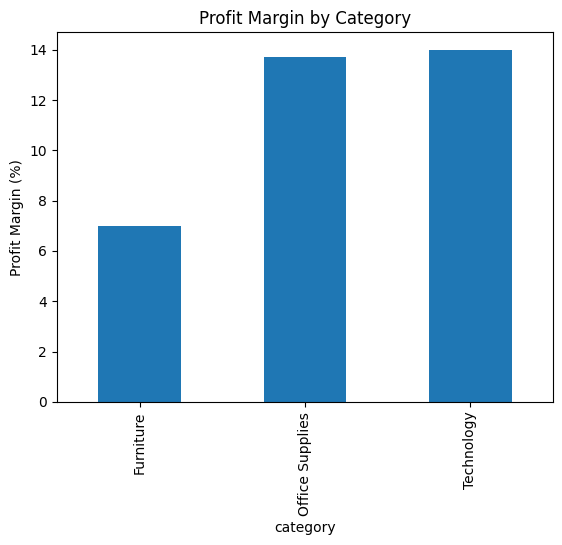

In [19]:
import matplotlib.pyplot as plt

category_summary["profit_margin_pct"].sort_values().plot(
    kind="bar"
)

plt.title("Profit Margin by Category")
plt.ylabel("Profit Margin (%)")
plt.show()

# Then let's find the worst-performing subcategories

In [20]:
subcat_profit = (
    df.groupby("sub_category")
      .agg({
          "sales": "sum",
          "profit": "sum"
      })
)

subcat_profit.sort_values(
    "profit"
).head(10)

,sales,profit
sub_category,,
Tables,757034.0,-64083.3887
Fasteners,83254.0,11525.4241
Labels,73433.0,15010.5120
Supplies,243090.0,22583.2631
Envelopes,170926.0,29601.1163
Furnishings,385609.0,46967.4255
Art,372163.0,57953.9109
Machines,779071.0,58867.8730
Paper,244307.0,59207.6827
